#Importing Libraries

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#preprocessing library
from sklearn.preprocessing import LabelEncoder,StandardScaler
# Splitting Training and Testing data
from sklearn.model_selection import train_test_split
#Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#importing metrics
from sklearn.metrics import ( accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, classification_report)

#WARNINGS
import warnings
warnings.filterwarnings('ignore')

#Data Reading

In [111]:
df= pd.read_csv('/content/drive/MyDrive/ICT-IIT Palakad- Advanced AI/data/employee_attrition_dataset (1).csv')

In [112]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


#Data Understanding

In [113]:
#Dataset Shape
df.shape

(1000, 26)

In [114]:
#coloumn information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

In [115]:
#Datatypes
df.dtypes

,0
Employee_ID,int64
Age,int64
Gender,object
Marital_Status,object
Department,object
Job_Role,object
Job_Level,int64
Monthly_Income,int64
Hourly_Rate,int64
Years_at_Company,int64


In [116]:
df.isna()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [117]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


In [118]:
print("Duplicate rows ", df.duplicated().sum())

Duplicate rows  0


In [119]:
print("Statistical Summary\n", df.describe())

Statistical Summary
        Employee_ID          Age    Job_Level  Monthly_Income  Hourly_Rate  \
count  1000.000000  1000.000000  1000.000000     1000.000000  1000.000000   
mean    500.500000    39.991000     3.055000    11499.899000    57.837000   
std     288.819436    11.780055     1.399977     4920.529231    24.702037   
min       1.000000    20.000000     1.000000     3001.000000    15.000000   
25%     250.750000    30.000000     2.000000     7395.750000    36.000000   
50%     500.500000    41.000000     3.000000    11256.000000    58.000000   
75%     750.250000    50.250000     4.000000    15855.000000    80.000000   
max    1000.000000    59.000000     5.000000    19999.000000    99.000000   

       Years_at_Company  Years_in_Current_Role  Years_Since_Last_Promotion  \
count       1000.000000            1000.000000                  1000.00000   
mean          14.922000               7.539000                     4.40800   
std            8.350548               4.001061     

#Exploratory Data Analysis EDA

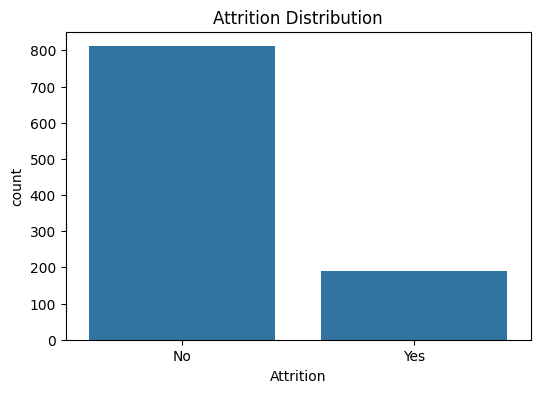

In [120]:
# Attrition Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition',data=df)
plt.title('Attrition Distribution')
plt.show()

# Business Insight  Helps understand whether attrition is balanced or imbalanced. High attrition indicates organizational risk.

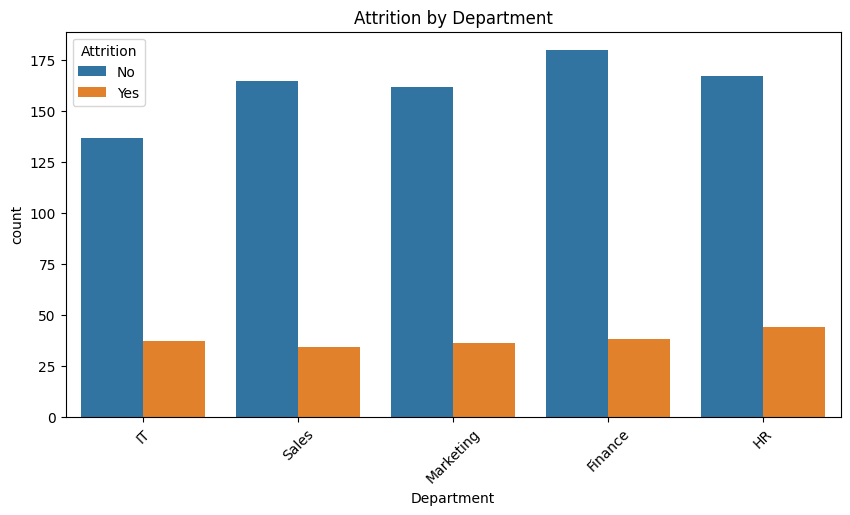

In [121]:
# Atrition by department
plt.figure(figsize=(10,5))
sns.countplot(x='Department' , hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Department")
plt.show()



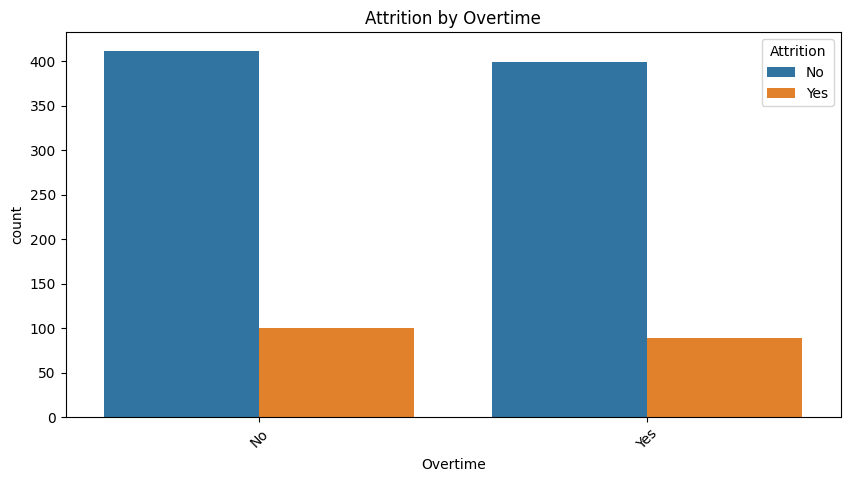

In [122]:
#Attrition by Overtime
plt.figure(figsize=(10,5))
plt.xticks(rotation=45)
sns.countplot(x='Overtime', hue='Attrition', data=df)
plt.title('Attrition by Overtime')
plt.show()

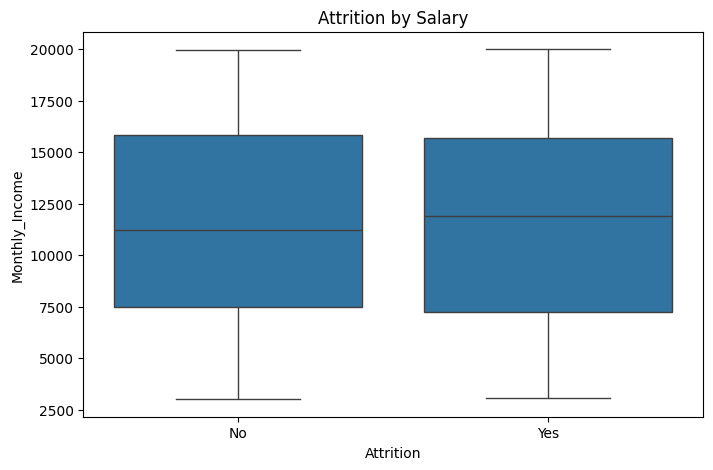

In [123]:
#Attrition by Salary
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition',y='Monthly_Income', data=df)
plt.title("Attrition by Salary")
plt.show()


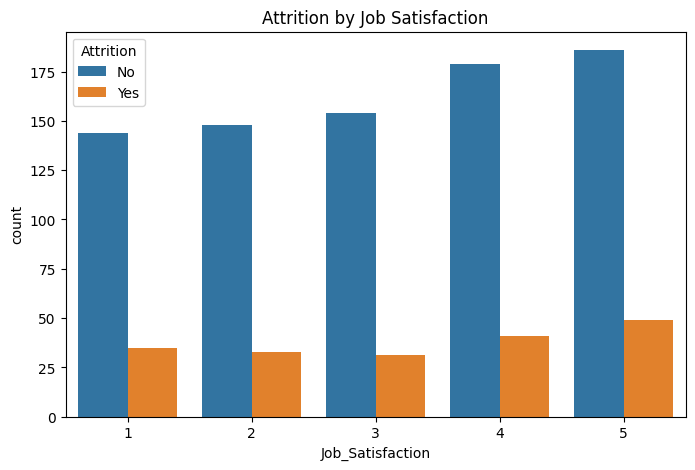

In [124]:
#Attrition by Jobstatisfaction
plt.figure(figsize=(8,5))
sns.countplot(x='Job_Satisfaction', hue='Attrition', data=df)
plt.title('Attrition by Job Satisfaction')
plt.show()

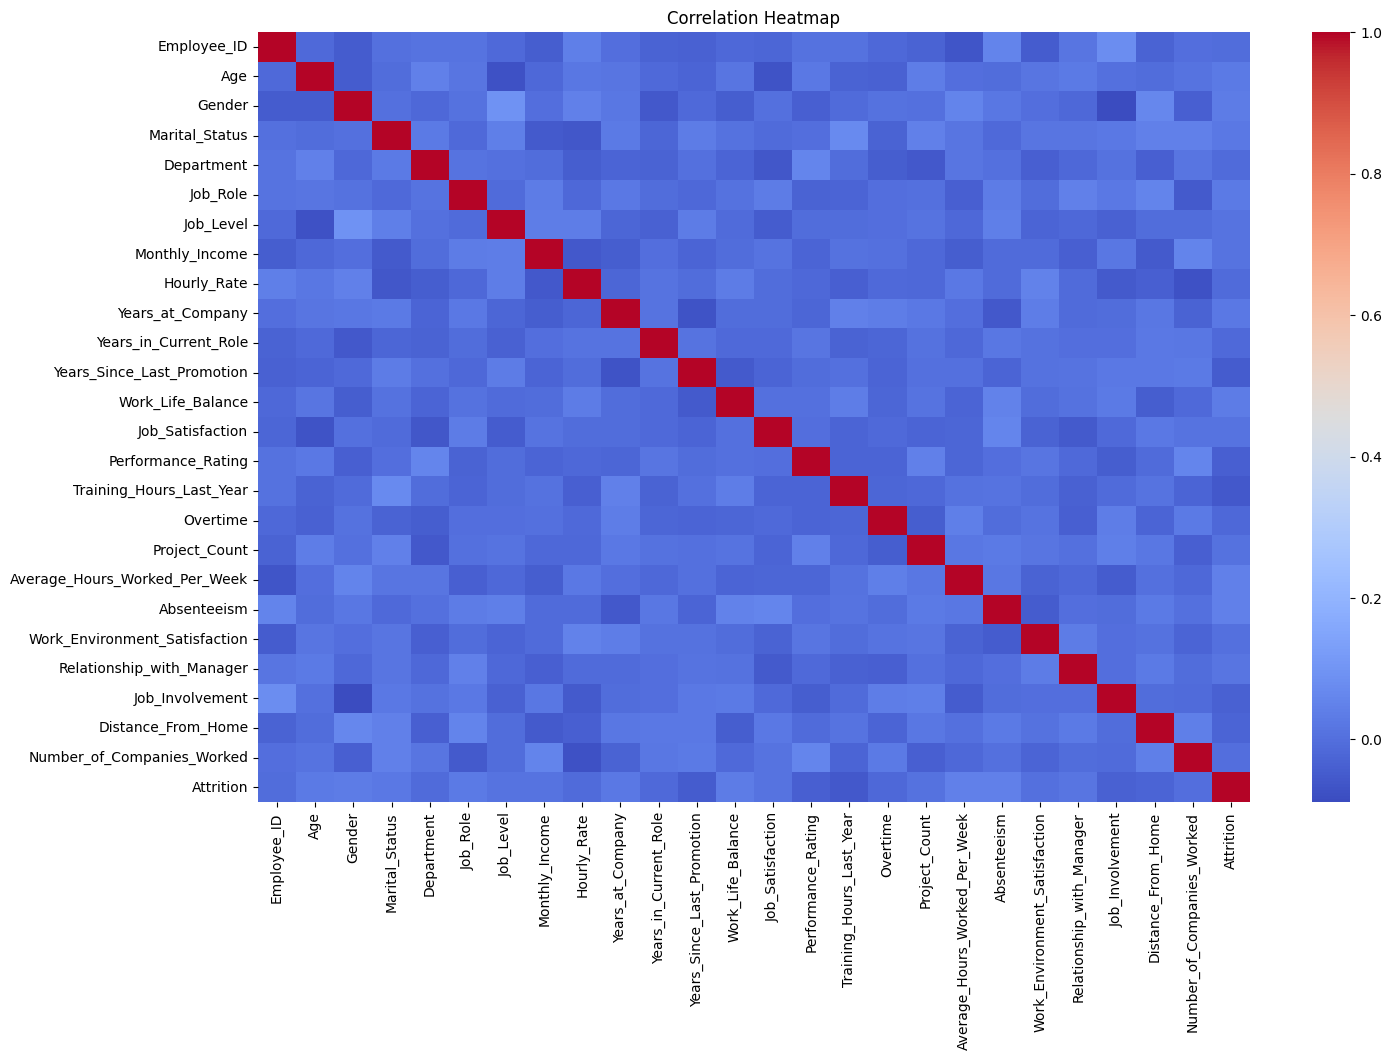

In [125]:
#Co relation Heat Map
# Convert categorical columns temporarily for correlation
label_temp = LabelEncoder()

df_corr = df.copy()

for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = label_temp.fit_transform(df_corr[col])

plt.figure(figsize=(16,10))
sns.heatmap(df_corr.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#

#Data Preprocessing

In [126]:
#Fill numerical missing values with median
for col in df.select_dtypes(include=np.number).columns:
  df[col].fillna(df[col].median(), inplace= True)

#Fill categorical coloumns with mode
for col in df.select_dtypes(include=object).columns:
  df[col].fillna(df[col].mode()[0], inplace =True)
df

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,27,Female,Divorced,HR,Analyst,2,4172,76,24,...,No,4,46,10,3,1,4,24,4,No
996,997,47,Male,Single,IT,Manager,4,11007,71,19,...,Yes,7,36,16,3,2,4,39,3,Yes
997,998,50,Female,Divorced,IT,Executive,1,4641,43,25,...,Yes,1,46,9,2,3,3,33,2,No
998,999,28,Female,Married,HR,Executive,4,19855,92,13,...,No,4,52,17,4,1,4,41,4,No


In [127]:
#Encode Categorical columns
label_encoder =LabelEncoder()
for col in df.columns:
  if df[col].dtype == object:
    df[col]=label_encoder.fit_transform(df[col])
df[col]

,Attrition
0,0
1,0
2,0
3,0
4,0
...,...
995,0
996,1
997,0
998,0


In [128]:
#Feature and Target Seperation
X = df.drop('Attrition', axis=1)
y = df['Attrition']



In [129]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.73031962,  1.52953545, -1.03252879, ...,  1.36204028,
        -0.31894353,  0.46455504],
       [-1.72685552,  0.68021819, -1.03252879, ..., -0.45765281,
         0.03488777, -0.43574542],
       [-1.72339142, -0.50882597,  0.968496  , ...,  1.36204028,
         1.45021297,  0.46455504],
       ...,
       [ 1.72339142,  0.85008164, -1.03252879, ...,  0.45219373,
         0.60101785, -0.43574542],
       [ 1.72685552, -1.01841632, -1.03252879, ...,  1.36204028,
         1.16714793,  1.3648555 ],
       [ 1.73031962,  0.68021819, -1.03252879, ...,  0.45219373,
         1.30868045, -0.43574542]])

In [130]:
#Train-test Splitting
X_train, X_test,y_train,y_test = train_test_split(X_scaled , y, test_size =0.2 , random_state =42)
print("Training Shape ", X_train.shape)
print("Testing Shape", X_test.shape)

Training Shape  (800, 25)
Testing Shape (200, 25)


#Model Building

##Logistic Regression

In [131]:
log_model = LogisticRegression()
log_model.fit (X_train,y_train)
log_pred = log_model.predict(X_test)

## Decision Tree Classifier

In [132]:
dt_model =DecisionTreeClassifier(random_state =42)
dt_model.fit (X_train,y_train)
dt_pred =dt_model.predict(X_test)

##Random Forest Classifier

In [133]:
rf_model = RandomForestClassifier(random_state =42)
rf_model.fit(X_train, y_train)
rf_pred =rf_model.predict(X_test)

#Model Evaluation

##Function for Model Evaluation

In [134]:
def evaluate_model(y_test, predictions, model_name):
  print(f'\n============={model_name}============')

  accuracy =accuracy_score(y_test,predictions)
  precision =precision_score(y_test, predictions)
  recall =recall_score(y_test, predictions)
  f1= f1_score(y_test, predictions)
  print("Accuracy is ", accuracy)
  print("Precision is ", precision)
  print("Recall ", recall)
  print("f1", f1)

  print("\n Classification Report :\n")
  print(classification_report(y_test,predictions))

  cm=confusion_matrix(y_test,predictions)
  plt.figure(figsize=(5,4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Confusion Matrix - {model_name}')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()



##Evaluate Logictic Regression


=============Logictic Regression============
Accuracy is  0.845
Precision is  0.0
Recall  0.0
f1 0.0

 Classification Report :

              precision    recall  f1-score   support

           0       0.84      1.00      0.92       169
           1       0.00      0.00      0.00        31

    accuracy                           0.84       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.71      0.84      0.77       200



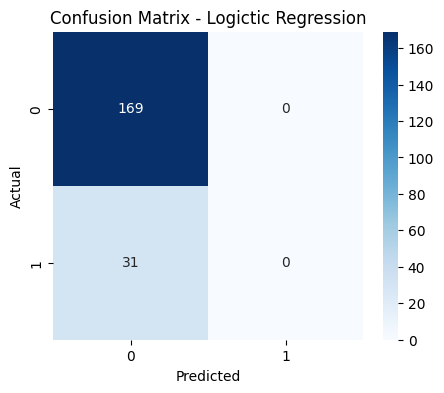

In [135]:
evaluate_model(y_test,log_pred, 'Logictic Regression' )

##Evaluate Decision Tree Classifier


=============Decision Tree Classifier============
Accuracy is  0.68
Precision is  0.22033898305084745
Recall  0.41935483870967744
f1 0.28888888888888886

 Classification Report :

              precision    recall  f1-score   support

           0       0.87      0.73      0.79       169
           1       0.22      0.42      0.29        31

    accuracy                           0.68       200
   macro avg       0.55      0.57      0.54       200
weighted avg       0.77      0.68      0.72       200



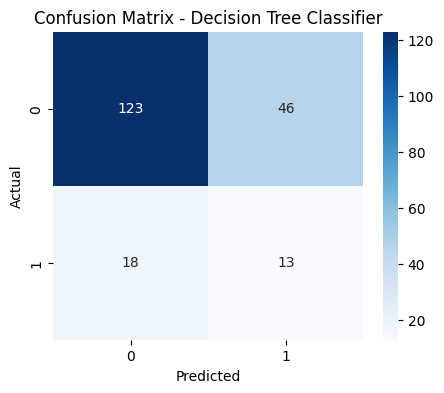

In [136]:
evaluate_model(y_test , dt_pred, 'Decision Tree Classifier')

##Evaluate Random Forest


=============Random Forest============
Accuracy is  0.845
Precision is  0.0
Recall  0.0
f1 0.0

 Classification Report :

              precision    recall  f1-score   support

           0       0.84      1.00      0.92       169
           1       0.00      0.00      0.00        31

    accuracy                           0.84       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.71      0.84      0.77       200



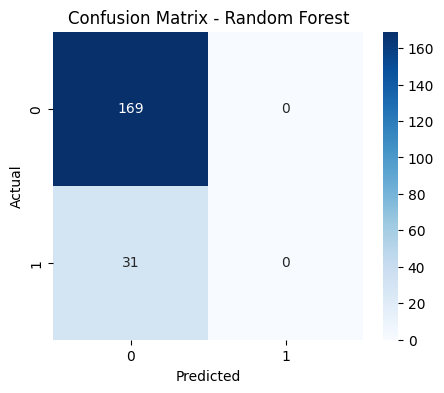

In [137]:
evaluate_model(y_test, rf_pred, 'Random Forest')

#Model Comparision

In [138]:
results =pd.DataFrame({ 'Model' : ['Logistic Regression', 'Decision Tree ', 'Random Forest'],
                        ' Accuracy ': [accuracy_score(y_test, log_pred),
                                       accuracy_score(y_test,dt_pred),
                                       accuracy_score(y_test,rf_pred)
                                       ],
                        'Precision': [precision_score(y_test, log_pred),
                                      precision_score(y_test,dt_pred),
                                      precision_score(y_test,rf_pred)
                                            ],
                        'F1 Score':[f1_score(y_test, log_pred),
                                    f1_score(y_test, dt_pred),
                                    f1_score(y_test,rf_pred)],
                        'Recall Score' : [recall_score(y_test, log_pred),
                                          recall_score(y_test, dt_pred),
                                          recall_score(y_test, rf_pred)
                                          ],
                        'Confusion Matrix': [confusion_matrix(y_test,log_pred),
                                             confusion_matrix(y_test,dt_pred),
                                             confusion_matrix(y_test,rf_pred)]})

In [139]:
print(results)

                 Model   Accuracy   Precision  F1 Score  Recall Score  \
0  Logistic Regression       0.845   0.000000  0.000000      0.000000   
1       Decision Tree        0.680   0.220339  0.288889      0.419355   
2        Random Forest       0.845   0.000000  0.000000      0.000000   

        Confusion Matrix  
0    [[169, 0], [31, 0]]  
1  [[123, 46], [18, 13]]  
2    [[169, 0], [31, 0]]  


#Feature Importance - Random Forest


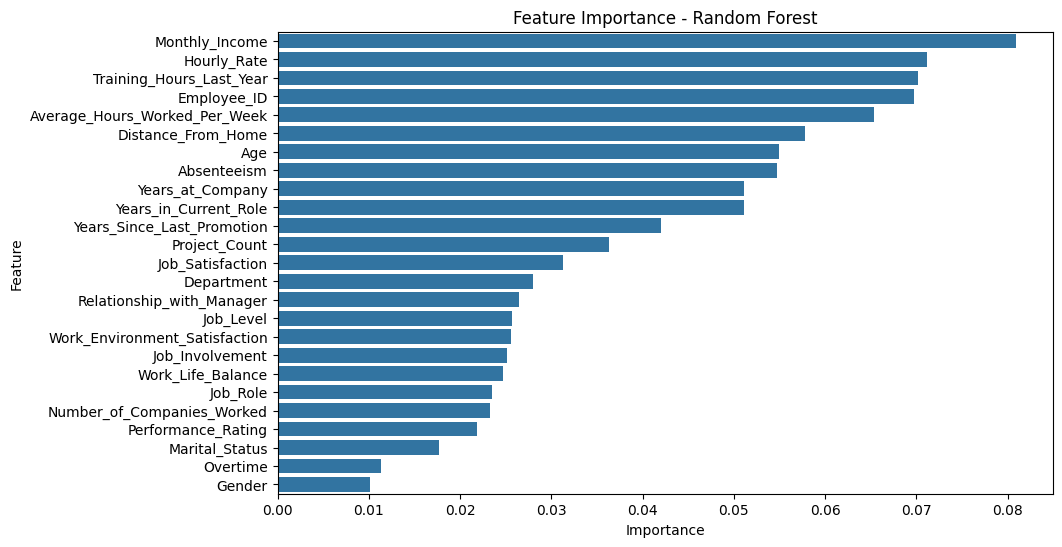

In [140]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance - Random Forest')
plt.show()

#